# Animal Danger Prediction using Machine Learning
Adapted from the Titanic Survival Prediction notebook's structure and applied to `data.csv` (animal symptoms -> Dangerous Yes/No).

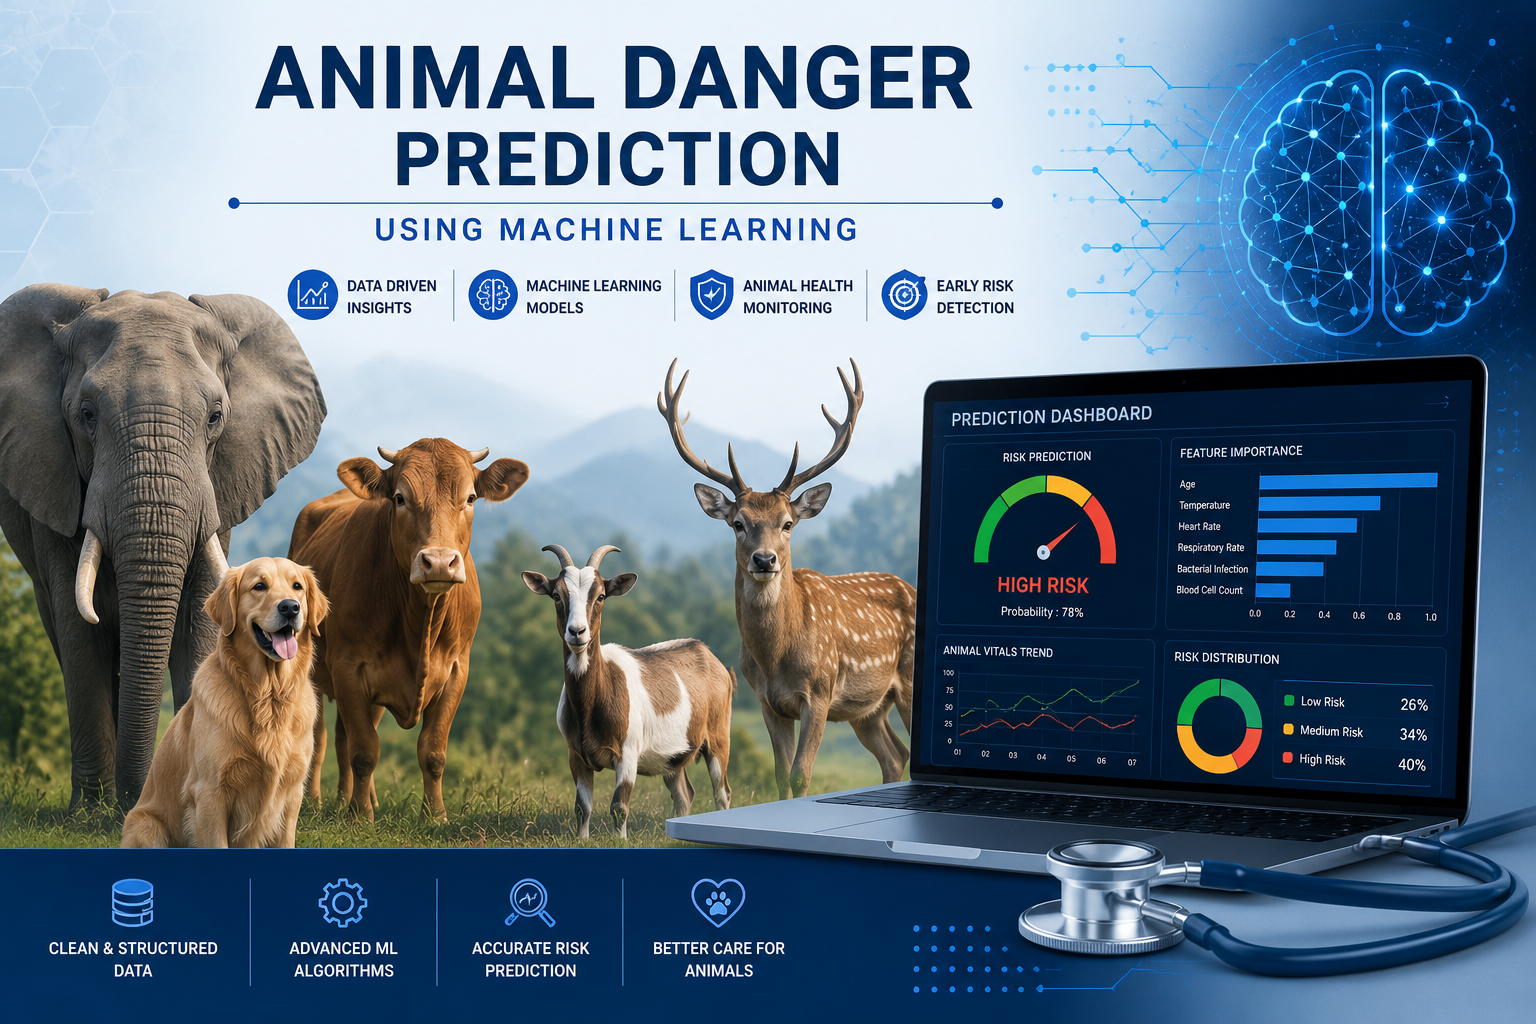

In [12]:
from IPython.display import Image, display

display(Image(filename="/Users/devansharora/Downloads/cia image.png", width=700))

# BLOCK 1: Import dependencies

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# BLOCK 2: Load the data

In [12]:
data = pd.read_csv('/Users/devansharora/Downloads/data.csv')

In [13]:
data

,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
0,Dog,Fever,Diarrhea,Vomiting,Weight loss,Dehydration,Yes
1,Dog,Fever,Diarrhea,Coughing,Tiredness,Pains,Yes
2,Dog,Fever,Diarrhea,Coughing,Vomiting,Anorexia,Yes
3,Dog,Fever,Difficulty breathing,Coughing,Lethargy,Sneezing,Yes
4,Dog,Fever,Diarrhea,Coughing,Lethargy,Blue Eye,Yes
...,...,...,...,...,...,...,...
866,Buffaloes,Fever,Difficulty breathing,Poor Appetite,Eye and Skin change,Unable to exercise,Yes
867,Buffaloes,Fever,Loss of appetite,Lession on the skin,Lethargy,Joint Pain,Yes
868,Buffaloes,Lesions in the nasal cavity,Lesions on nose,Vomiting,Noisy Breathing,Lesions on nose,Yes
869,Buffaloes,Hair loss,Dandruff,Vomiting,Crusting of the skin,Ulcerated skin,Yes


# BLOCK 3: Shape, Head, Info

In [14]:
print(data.shape)        # rows, columns
data.head()              # first 5 rows
data.info()              # dtypes and non-null counts

(871, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 871 entries, 0 to 870
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   AnimalName  871 non-null    object
 1   symptoms1   871 non-null    object
 2   symptoms2   871 non-null    object
 3   symptoms3   871 non-null    object
 4   symptoms4   871 non-null    object
 5   symptoms5   871 non-null    object
 6   Dangerous   869 non-null    object
dtypes: object(7)
memory usage: 47.8+ KB


# BLOCK 4: Check for missing value
# BLOCK 5: Handle missing values

In [17]:
print(data.isnull().sum())
# -> 2 missing values found in the 'Dangerous' target column

# Drop rows where the TARGET is missing (can't use unlabeled rows for
# supervised training or evaluation). No other columns had missing data.
data = data.dropna(subset=['Dangerous']).reset_index(drop=True)

AnimalName    0
symptoms1     0
symptoms2     0
symptoms3     0
symptoms4     0
symptoms5     0
Dangerous     2
dtype: int64


# BLOCK 6: Clean up inconsistent categorical text

In [4]:
# Strip stray whitespace and standardize AnimalName casing
# (e.g. 'cat' and 'Cat' currently count as different categories).
text_cols = ['AnimalName', 'symptoms1', 'symptoms2', 'symptoms3',
             'symptoms4', 'symptoms5', 'Dangerous']
for col in text_cols:
    data[col] = data[col].astype(str).str.strip()

data['AnimalName'] = data['AnimalName'].str.title()

# BLOCK 7: Data analysis / visualization (styled)

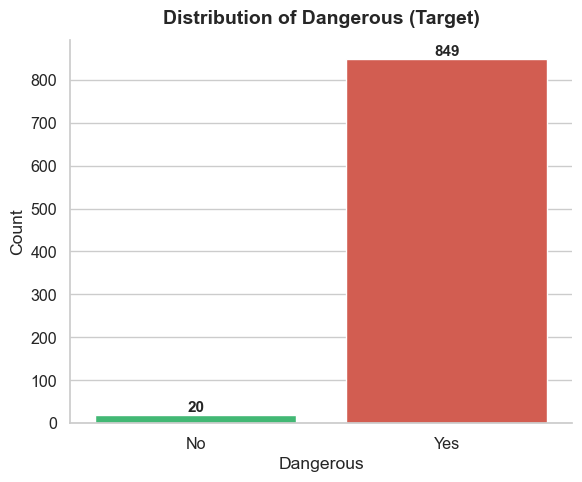

Dangerous
Yes    849
No      20
Name: count, dtype: int64


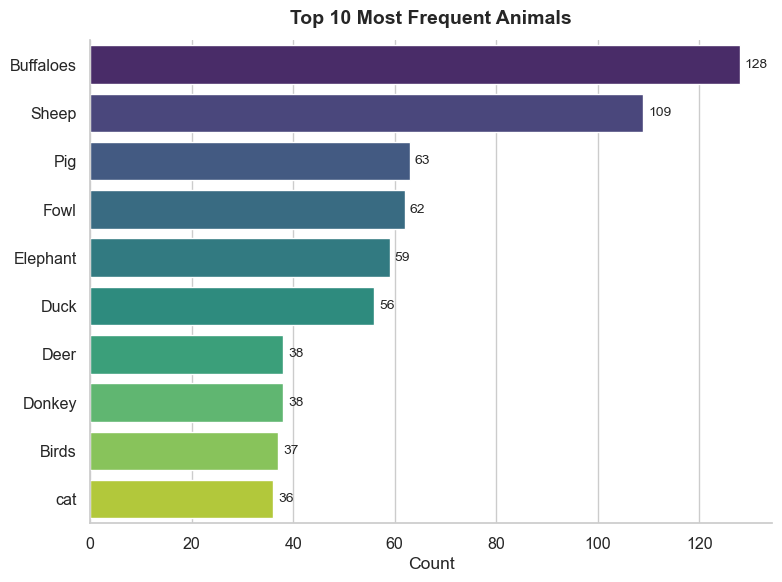

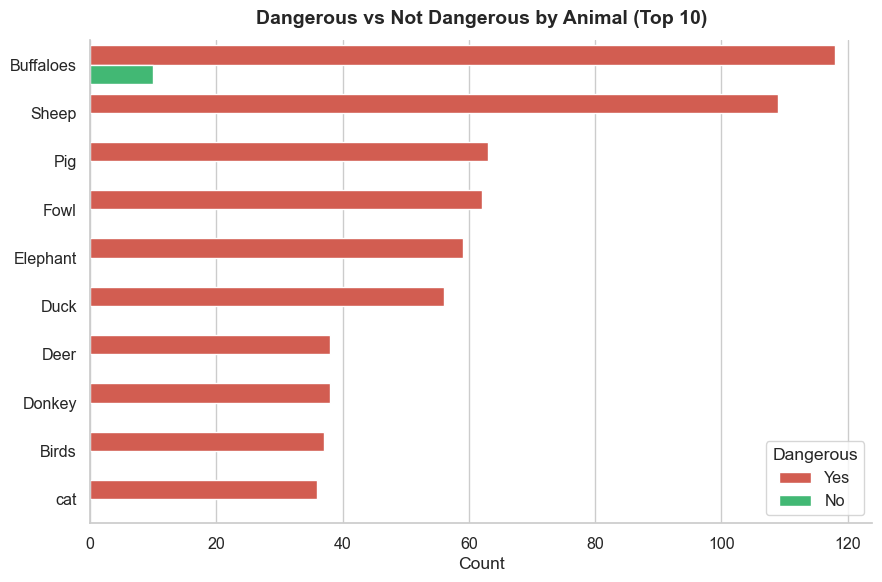

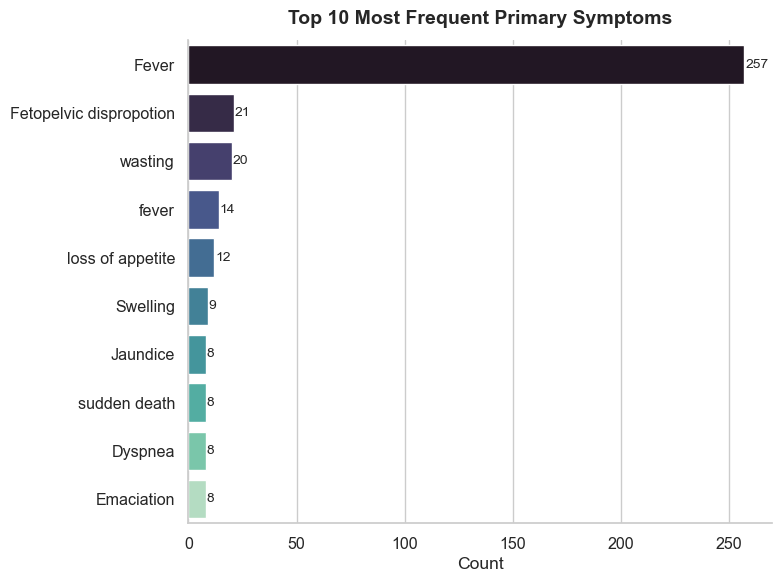

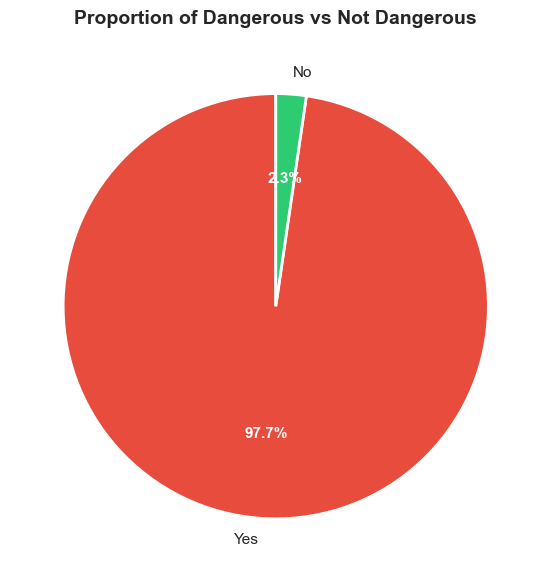

In [19]:
sns.set_theme(style='whitegrid', font_scale=1.05)
PALETTE = {'Yes': '#e74c3c', 'No': '#2ecc71'}   # red = dangerous, green = not dangerous

# --- Chart 1: Class balance of the target, with value labels on bars ---
fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(x='Dangerous', hue='Dangerous', data=data, palette=PALETTE,
              order=['No', 'Yes'], legend=False, ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Dangerous (Target)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Dangerous'); ax.set_ylabel('Count')
sns.despine()
plt.tight_layout()
plt.show()

print(data['Dangerous'].value_counts())
# -> Yes: 849, No: 20

# --- Chart 2: Most common animals, horizontal bars with counts labeled ---
top_animals = data['AnimalName'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_animals.values, y=top_animals.index,
            hue=top_animals.index, palette='viridis', legend=False, ax=ax)
for i, v in enumerate(top_animals.values):
    ax.text(v + 1, i, str(v), va='center', fontsize=10)
ax.set_title('Top 10 Most Frequent Animals', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Count'); ax.set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

# --- Chart 3: Top animals broken down by Dangerous (like Titanic's Pclass-vs-Survived) ---
# Only using the top 10 animals here, since AnimalName has 46+ categories
# and a full countplot would be unreadable.
top10_names = top_animals.index.tolist()
subset = data[data['AnimalName'].isin(top10_names)]

fig, ax = plt.subplots(figsize=(9, 6))
sns.countplot(y='AnimalName', hue='Dangerous', data=subset, order=top10_names,
              palette=PALETTE, ax=ax)
ax.set_title('Dangerous vs Not Dangerous by Animal (Top 10)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Count'); ax.set_ylabel('')
ax.legend(title='Dangerous', loc='lower right', frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

# --- Chart 4: Most frequent primary symptom (symptoms1), labeled ---
top_symptom1 = data['symptoms1'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=top_symptom1.values, y=top_symptom1.index,
            hue=top_symptom1.index, palette='mako', legend=False, ax=ax)
for i, v in enumerate(top_symptom1.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=10)
ax.set_title('Top 10 Most Frequent Primary Symptoms', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Count'); ax.set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

# --- Chart 5: Proportion of Dangerous vs Not Dangerous, styled pie ---
counts = data['Dangerous'].value_counts()
colors = [PALETTE.get(label, '#95a5a6') for label in counts.index]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, autopct='%1.1f%%', startangle=90,
    colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_color('white'); at.set_fontweight('bold')
ax.set_title('Proportion of Dangerous vs Not Dangerous', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# BLOCK 8: Encode categorical columns

['No' 'Yes']


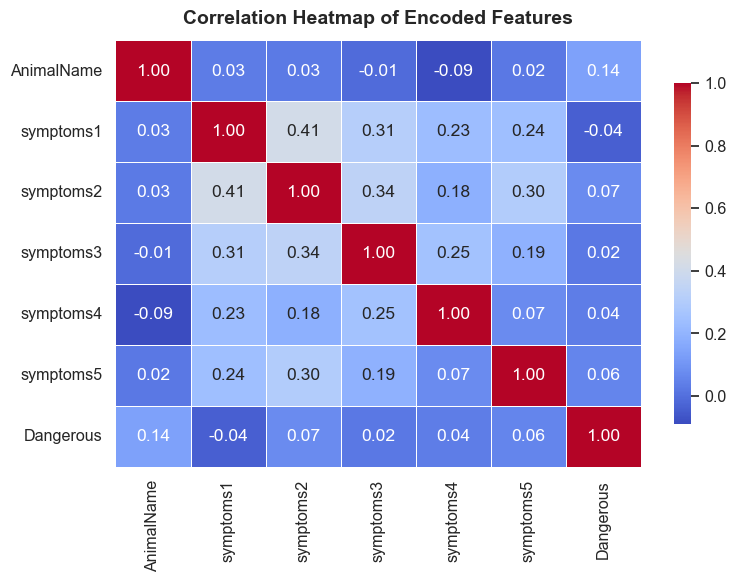

In [20]:
# LabelEncoder is used instead of a manual dictionary (like the Titanic
# notebook's Sex/Embarked mapping) because AnimalName and each symptom
# column have 200+ unique categories -- too many to map by hand.
label_encoders = {}
encoded_data = data.copy()

for col in ['AnimalName', 'symptoms1', 'symptoms2', 'symptoms3',
            'symptoms4', 'symptoms5']:
    le = LabelEncoder()
    encoded_data[col] = le.fit_transform(encoded_data[col])
    label_encoders[col] = le  # keep encoder to decode/predict on new data later

# Encode target: No -> 0, Yes -> 1
target_encoder = LabelEncoder()
encoded_data['Dangerous'] = target_encoder.fit_transform(encoded_data['Dangerous'])
print(target_encoder.classes_)  # confirms ['No', 'Yes'] -> [0, 1]

# --- Chart 6: Correlation heatmap of encoded features (styled) ---
# NOTE: features here are label-encoded categoricals (arbitrary integer
# codes), not true numeric scales, so correlations are indicative only --
# less rigorous than for genuinely continuous variables like Titanic's
# Age or Fare.
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(encoded_data.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap of Encoded Features', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# BLOCK 9: Separate features (X) and target (Y)

In [21]:
X = encoded_data.drop(columns=['Dangerous'])
Y = encoded_data['Dangerous']

# BLOCK 10: Train/test split

In [22]:
# Same 80/20 split and random_state as the Titanic notebook.
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)
print(X.shape, X_train.shape, X_test.shape)

(869, 6) (695, 6) (174, 6)


# BLOCK 11: Train the Logistic Regression model

In [23]:
# Plain LogisticRegression, same as the Titanic notebook (no class weighting).
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# BLOCK 11.5: Predict danger level from sickness/symptoms and chart it

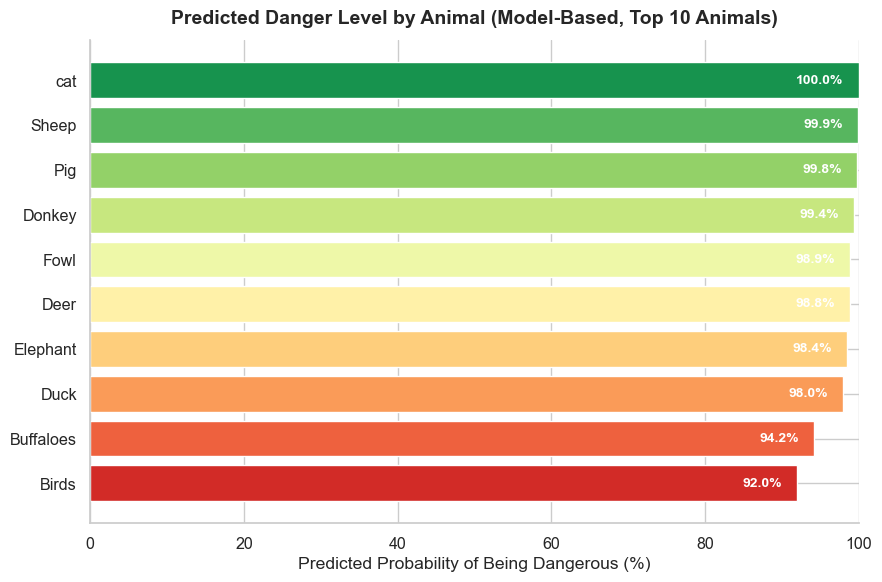

In [24]:
# Use the trained model's predicted PROBABILITY of "Dangerous = Yes"
# (not just the raw historical Yes/No counts) as a "danger score" for
# each row, based on that animal's symptom combination.
yes_index = list(target_encoder.classes_).index('Yes')
data['PredictedDangerProb'] = model.predict_proba(X)[:, yes_index]

# Average predicted danger probability per animal (top 10 most frequent
# animals, so the chart stays readable)
top_animals = data['AnimalName'].value_counts().head(10).index.tolist()
avg_risk = (
    data[data['AnimalName'].isin(top_animals)]
    .groupby('AnimalName')['PredictedDangerProb']
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = sns.color_palette('RdYlGn_r', len(avg_risk))  # red = high danger, green = low
bars = ax.barh(avg_risk.index, avg_risk.values * 100, color=colors)
ax.invert_yaxis()  # highest risk animal at the top

for bar, val in zip(bars, avg_risk.values * 100):
    ax.text(val - 2, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%',
            va='center', ha='right', color='white', fontweight='bold', fontsize=10)

ax.set_xlabel('Predicted Probability of Being Dangerous (%)')
ax.set_title('Predicted Danger Level by Animal (Model-Based, Top 10 Animals)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(0, 100)
sns.despine()
plt.tight_layout()
plt.show()

# BLOCK 12: Evaluate on training data

In [10]:
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)
print('Accuracy score of training data:', training_data_accuracy)

Accuracy score of training data: 0.9798561151079137


# BLOCK 13: Evaluate on test data

In [11]:
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
print('Accuracy score of test data:', test_data_accuracy)

# Included for transparency: with the 849:20 imbalance, accuracy alone
# can look excellent while the model still never predicts "No" at all.
print(classification_report(Y_test, X_test_prediction,
                             target_names=target_encoder.classes_, zero_division=0))
print(confusion_matrix(Y_test, X_test_prediction))

Accuracy score of test data: 0.9655172413793104
              precision    recall  f1-score   support

          No       0.00      0.00      0.00         6
         Yes       0.97      1.00      0.98       168

    accuracy                           0.97       174
   macro avg       0.48      0.50      0.49       174
weighted avg       0.93      0.97      0.95       174

[[  0   6]
 [  0 168]]
